In [1]:
import zipfile
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: UNZIP DATASET ---
zip_path = '/content/archive.zip' # Update if your filename differs
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/waste_data')

# Set path to the resized folder (TrashNet standard structure)
data_path = '/content/waste_data/dataset-resized'

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5438 - loss: 1.2047 - val_accuracy: 0.7117 - val_loss: 0.7312
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8219 - loss: 0.5049 - val_accuracy: 0.7177 - val_loss: 0.7059
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8547 - loss: 0.4121 - val_accuracy: 0.7614 - val_loss: 0.6443
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8911 - loss: 0.3215 - val_accuracy: 0.7455 - val_loss: 0.7200
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9108 - loss: 0.2511 - val_accuracy: 0.7594 - val_loss: 0.6869
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9295 - loss: 0.2026 - val_accuracy: 0.7416 - val_loss: 0.7361
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9371 - loss: 0.1926 - val_accuracy: 0.7396 - val_loss: 0.7580
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9593 - loss: 0.1447 - val_accuracy: 0.7435 - v

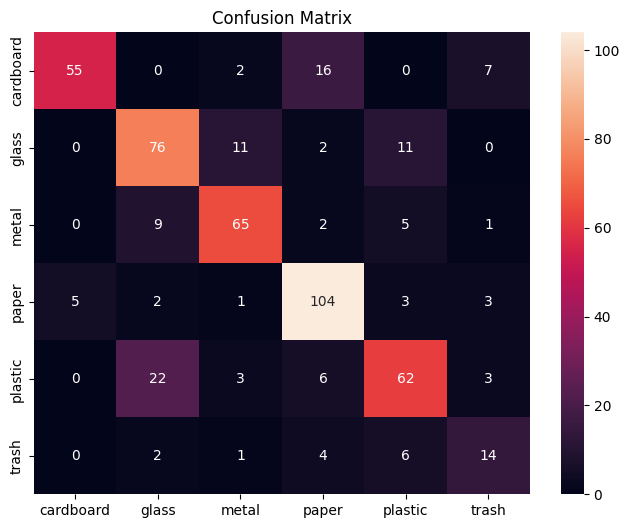

In [2]:
# --- STEP 2: DATA AUGMENTATION (Proposal Section 7) ---
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 80-20 split
    rotation_range=25,
    horizontal_flip=True,
    zoom_range=0.1
)

train_gen = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, subset='training')
val_gen = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, subset='validation', shuffle=False)

# --- STEP 3: BUILD MODEL (Transfer Learning for Speed) ---
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax') # 6 classes: glass, paper, cardboard, plastic, metal, trash
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# --- STEP 4: INITIAL TRAINING ---
history = model.fit(train_gen, validation_data=val_gen, epochs=15)

# --- STEP 4.1: FINE-TUNING ---
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])
history_fine = model.fit(train_gen, validation_data=val_gen, epochs=10)

# --- STEP 5: EVALUATION (Confusion Matrix) ---
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_gen.classes, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=val_gen.class_indices.keys(), yticklabels=val_gen.class_indices.keys())
plt.title('Confusion Matrix')
plt.show()

model.save('waste_model.h5')

In [3]:
from google.colab import files
files.download('waste_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>